Rows: 7976  | Columns: 16
  show_id     type                          title         director  \
0      s1    Movie           Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show                  Blood & Water          Unknown   
2      s5  TV Show                   Kota Factory          Unknown   
3      s8    Movie                        Sankofa     Haile Gerima   
4      s9  TV Show  The Great British Baking Show  Andy Devonshire   

                                                cast         country  \
0                                            Unknown   United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...    South Africa   
2  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...           India   
3  Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...   United States   
4  Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...  United Kingdom   

   date_added  release_year rating   duration  \
0  2021-09-25          2020  PG-13     90 min   
1  2021-09-24         

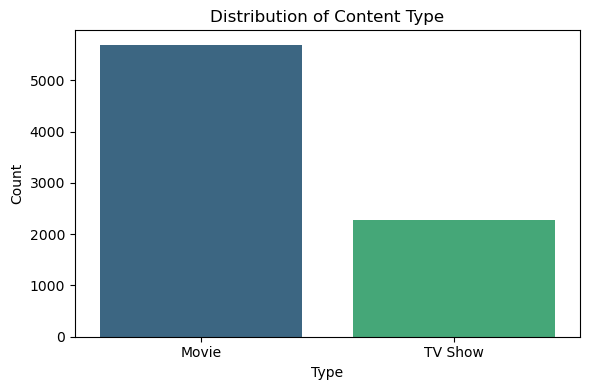

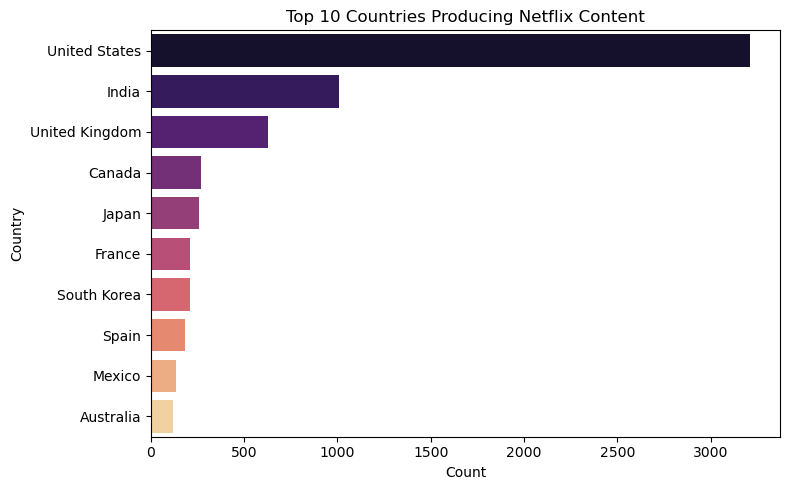

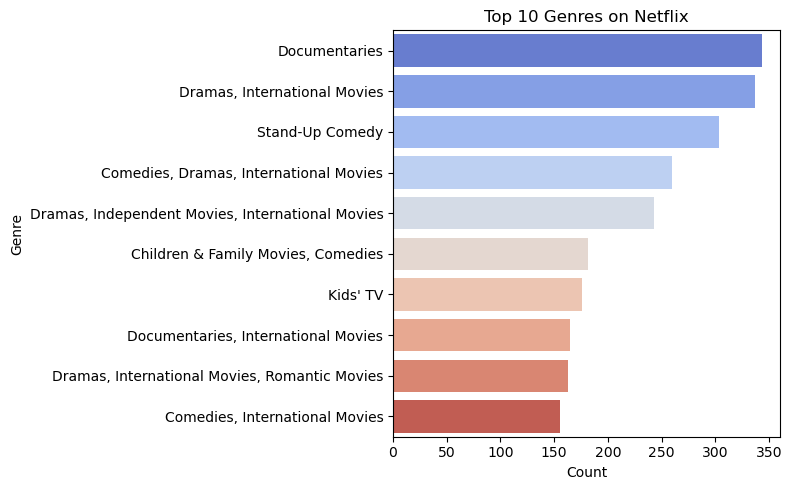

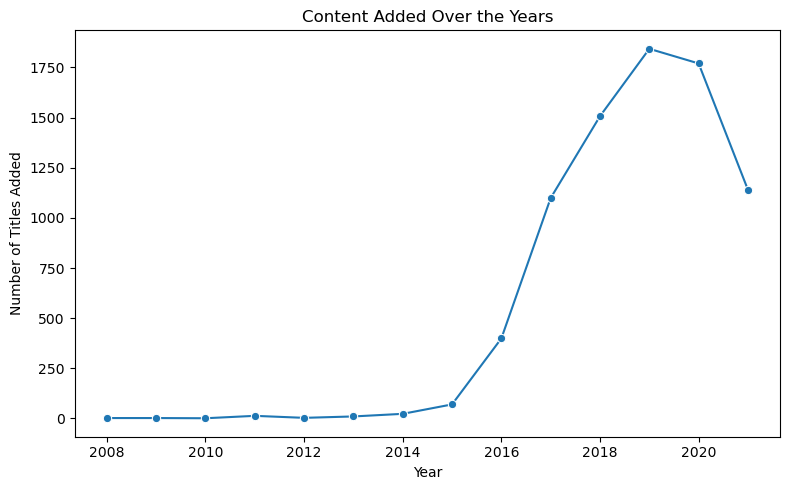

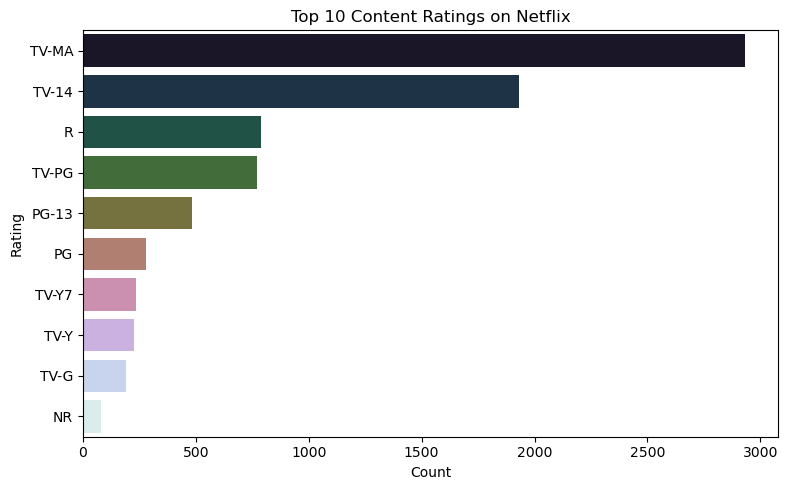

✅ All charts saved in: ../outputs/visuals/


In [3]:
# ✅ Netflix Content Analysis — Visualization Only
# ------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# -------------------------------
# Step 1 — Setup output folder
# -------------------------------
output_path = r"../outputs/visuals/"
os.makedirs(output_path, exist_ok=True)

# -------------------------------
# Step 2 — Load cleaned dataset
# -------------------------------
data_path = r"../data/processed/cleaned_data.csv"
df = pd.read_csv(data_path)

# -------------------------------
# Step 3 — Quick inspection
# -------------------------------
print("Rows:", df.shape[0], " | Columns:", df.shape[1])
print(df.head())

# -------------------------------
# Step 4 — Content Type Distribution
# -------------------------------
plt.figure(figsize=(6,4))
type_counts = df['type'].value_counts()
sns.barplot(x=type_counts.index, y=type_counts.values, hue=type_counts.index, palette='viridis', dodge=False)
plt.title("Distribution of Content Type")
plt.xlabel("Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(output_path + "content_type_distribution.png", bbox_inches='tight')
plt.show()

# -------------------------------
# Step 5 — Top 10 Countries Producing Netflix Content
# -------------------------------
plt.figure(figsize=(8,5))
country_counts = df['country'].value_counts().head(10)
sns.barplot(x=country_counts.values, y=country_counts.index, hue=country_counts.index, palette='magma', dodge=False)
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Count")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig(output_path + "country_wise_content.png", bbox_inches='tight')
plt.show()

# -------------------------------
# Step 6 — Top 10 Genres
# -------------------------------
plt.figure(figsize=(8,5))
genre_counts = df['listed_in'].value_counts().head(10)
sns.barplot(x=genre_counts.values, y=genre_counts.index, hue=genre_counts.index, palette='coolwarm', dodge=False)
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.tight_layout()
plt.savefig(output_path + "genre_distribution.png", bbox_inches='tight')
plt.show()

# -------------------------------
# Step 7 — Content Added Over the Years
# -------------------------------
plt.figure(figsize=(8,5))
df['year_added'] = pd.to_datetime(df['date_added'], errors='coerce').dt.year
yearly_counts = df['year_added'].value_counts().sort_index()
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o')
plt.title("Content Added Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.tight_layout()
plt.savefig(output_path + "content_by_year.png", bbox_inches='tight')
plt.show()

# -------------------------------
# Step 8 — Top 10 Ratings
# -------------------------------
plt.figure(figsize=(8,5))
rating_counts = df['rating'].value_counts().head(10)
sns.barplot(x=rating_counts.values, y=rating_counts.index, hue=rating_counts.index, palette='cubehelix', dodge=False)
plt.title("Top 10 Content Ratings on Netflix")
plt.xlabel("Count")
plt.ylabel("Rating")
plt.tight_layout()
plt.savefig(output_path + "rating_breakdown.png", bbox_inches='tight')
plt.show()

print(f"✅ All charts saved in: {output_path}")
